In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Method 1: If you have the dimensions and know it's a single image
def load_raw_image(raw_path, width, height, dtype=np.uint16, channels=3):
    """
    Load a raw image file.
    
    Args:
        raw_path: Path to .raw file
        width: Image width
        height: Image height
        dtype: Data type (np.uint8, np.uint16, np.float32, etc.)
        channels: Number of channels (1 for grayscale, 3 for RGB, N for HSI)
    """
    raw_data = np.fromfile(raw_path, dtype=dtype)
    
    if channels == 1:
        image = raw_data.reshape((height, width))
    else:
        image = raw_data.reshape((height, width, channels))
    
    return image

# Example usage:
raw_path = Path("D:\\oil\\22_Dec_2025\\2722\\capture\\2722.raw")
image = load_raw_image(raw_path, width=512, height=512, dtype=np.uint16, channels=204)



In [11]:
image.max()

4095

In [12]:
image.min()

246

In [ ]:
# Display in notebook
plt.figure(figsize=(10, 8))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

TypeError: descriptor 'newbyteorder' for 'numpy.generic' objects doesn't apply to a 'str' object

HSI Cube shape: (512, 512, 204)
Data type: <f4


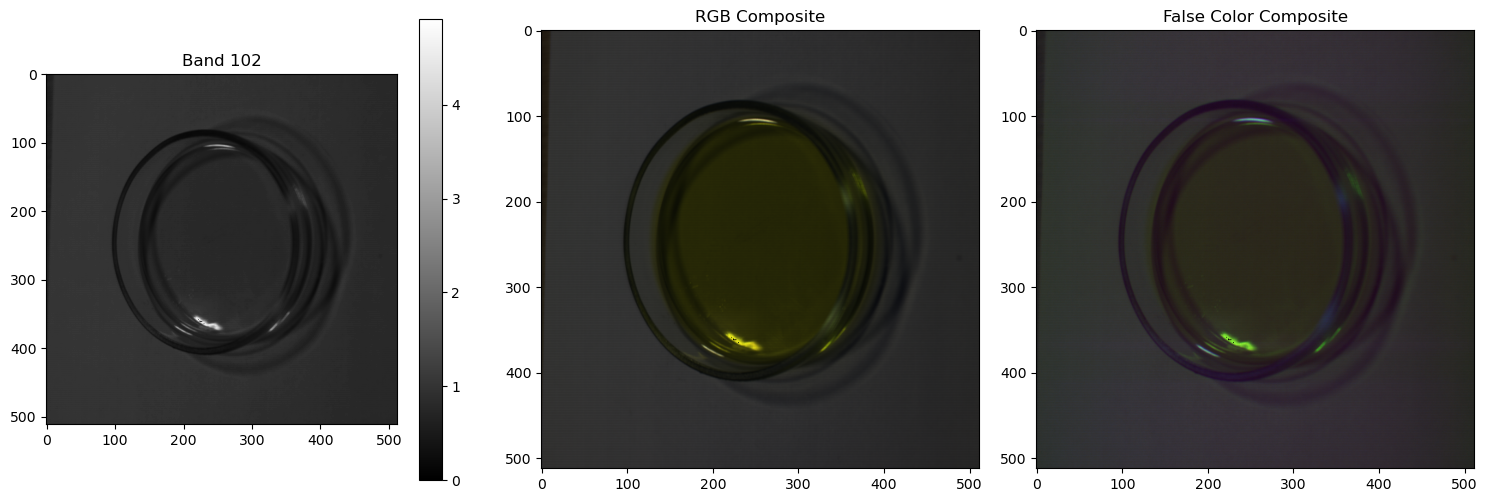

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from spectral.io import envi



# Example usage:
dat_path = Path("D:\\oil\\22_Dec_2025\\2722\\results\\REFLECTANCE_2722.dat")
hdr_path = Path("D:\\oil\\22_Dec_2025\\2722\\results\\REFLECTANCE_2722.hdr")
hsi_cube = envi.open(hdr_path, image=dat_path)
print(f"HSI Cube shape: {hsi_cube.shape}")  # (height, width, bands)
print(f"Data type: {hsi_cube.dtype}")

# Visualize
plt.figure(figsize=(15, 5))

# Single band
plt.subplot(1, 3, 1)
band_idx = hsi_cube.shape[2] // 2
plt.imshow(hsi_cube[:, :, band_idx], cmap='gray')
plt.title(f'Band {band_idx}')
plt.colorbar()

plt.subplot(1, 3, 2)
rgb = np.stack([
    hsi_cube[:, :, 70],
    hsi_cube[:, :, 53],
    hsi_cube[:, :, 19]
], axis=-1)
# Normalize to 0-255
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8) * 255
rgb = rgb.astype(np.uint8).squeeze(2)
plt.imshow(rgb)
plt.title('RGB Composite')

# False color
plt.subplot(1, 3, 3)
false_color = np.stack([
    hsi_cube[:, :, -1],  # Last band
    hsi_cube[:, :, hsi_cube.shape[2]//2],  # Middle band
    hsi_cube[:, :, 0]  # First band
], axis=-1)
false_color = (false_color - false_color.min()) / (false_color.max() - false_color.min() + 1e-8) * 255
false_color = false_color.astype(np.uint8).squeeze(2)
plt.imshow(false_color)
plt.title('False Color Composite')

plt.tight_layout()
plt.show()

In [2]:
import torch
hsi_cube = torch.from_numpy(hsi_cube.load().astype('float32'))

In [3]:
hsi_cube.max()

tensor(5.4181)

In [29]:
hsi_cube.min()

tensor(0.)

In [30]:
res_cube = hsi_cube

In [4]:
dat_path = Path("D:\\oil\\22_Dec_2025\\2722\\capture\\2722.raw")
hdr_path = Path("D:\\oil\\22_Dec_2025\\2722\\capture\\2722.hdr")
img = envi.open(hdr_path, image=dat_path)
cap_cube = torch.from_numpy(img.load().astype('float32'))

In [5]:
cap_cube.max()

tensor(4095.)

In [33]:
cap_cube.min()

tensor(246.)

In [6]:
import pandas as pd
df = pd.read_excel('C:\\Users\\4spam\\evoo\\pivot_table.xlsx')

In [7]:
from utils.dataset import UniversalDataset

ds = UniversalDataset(root_dir='D:\\oil\\', meta=df, mask_dir='C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\', load_mask = True, crop_size = 512)


 Dataset initialized with error: 
	120 IDs not found in dataset: 
[2860, 2862, 2863, 2864, 2865, 2866, 2867, 2868, 2869, 2870, 2871, 2872, 2873, 2874, 2875, 2876, 2877, 2878, 2879, 2880, 2881, 2882, 2883, 2884, 2885, 2886, 2887, 2888, 2889, 2890, 2891, 2892, 2893, 2894, 2895, 2896, 2897, 2898, 2899, 2900, 2901, 2902, 2903, 2904, 2905, 2906, 2907, 2908, 2909, 2910, 2911, 2913, 2914, 2915, 2916, 2917, 2918, 2919, 2920, 2921, 2923, 2925, 2926, 2927, 2928, 2929, 2930, 2931, 2932, 2933, 2934, 2935, 2936, 2937, 2938, 2939, 2940, 2941, 2942, 2943, 2944, 2945, 2946, 2947, 2949, 2950, 2951, 2952, 2953, 2954, 2955, 2956, 2957, 2958, 2959, 2960, 2962, 2966, 2966, 2967, 2968, 2969, 2976, 2977, 2978, 2979, 2980, 2981, 2982, 2983, 2984, 2985, 2986, 2987, 2970, 2971, 2972, 2973, 2974, 2975]


2621


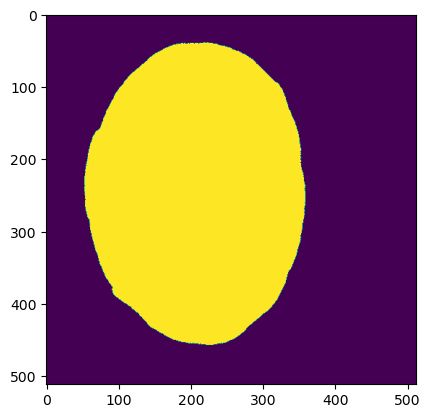

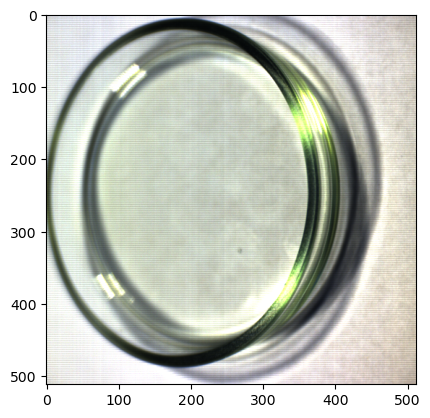

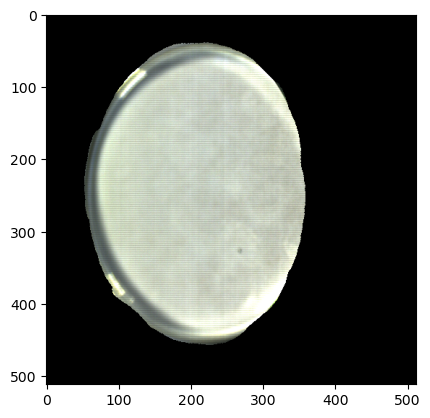

In [8]:
import matplotlib.pyplot as plt
print(ds[0]['id'])
plt.imshow(ds[0]['mask'][0]);
plt.show();
plt.imshow(ds[0]['rgb'].permute(1, 2, 0));
plt.show();
plt.imshow((ds[0]['mask'][0] * ds[0]['rgb']).permute(1, 2, 0));
plt.show();

In [9]:
import sys
from pathlib import Path
from argparse import Namespace as _NS

parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))

from DL.proj.new_awan.deliverables.new_awan.normalized_dirty_awan import *

In [10]:
checkpoint_path = 'C:/Users/4spam/DL/proj/new_awan/awan_dirty_random_crop_240p_600ch_6b_nopsnl_20251202_031528.pth'
ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

# Try to read args from checkpoint (new format)
if 'args' in ckpt:
    print("Loading args from checkpoint metadata...")
    args_dict = ckpt['args']
    args = _NS(**args_dict)
    print(f"Loaded args: render={args.render}, channels={args.channels}, blocks={args.blocks}, use_psnl={not args.no_psnl}")

print(f"Final args: render={args.render}, channels={args.channels}, blocks={args.blocks}, use_psnl={not args.no_psnl}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Loading args from checkpoint metadata...
Loaded args: render=False, channels=600, blocks=6, use_psnl=False
Final args: render=False, channels=600, blocks=6, use_psnl=False
Using device: cuda


In [11]:
css = np.load('utils/css_fx10_204.npy').astype('float32')
waves = np.load('utils/fx10_wavelengths_204.npy').astype('float32')


In [12]:
model = AWANCleanNet(bands_out=css.shape[0], channels=args.channels, n_blocks=args.blocks, use_psnl=not args.no_psnl)
model.load_state_dict(ckpt['model'], strict=False)
model.eval().to(device)
print(f"Model loaded. Checkpoint info:")
print(f"  Epoch: {ckpt.get('ep', 'N/A')}")
print(f"  Best RMSE: {ckpt.get('best_rmse', 'N/A'):.4f}" if 'best_rmse' in ckpt else "  Best RMSE: N/A")
print(f"  Timestamp: {ckpt.get('timestamp', 'N/A')}")

Model loaded. Checkpoint info:
  Epoch: 194
  Best RMSE: 0.0288
  Timestamp: 2025-12-02T03:15:28.731769


In [13]:
ds[90]['hsi'].shape

torch.Size([204, 512, 512])


 Dataset initialized with error: 
	120 IDs not found in dataset: 
[2860, 2862, 2863, 2864, 2865, 2866, 2867, 2868, 2869, 2870, 2871, 2872, 2873, 2874, 2875, 2876, 2877, 2878, 2879, 2880, 2881, 2882, 2883, 2884, 2885, 2886, 2887, 2888, 2889, 2890, 2891, 2892, 2893, 2894, 2895, 2896, 2897, 2898, 2899, 2900, 2901, 2902, 2903, 2904, 2905, 2906, 2907, 2908, 2909, 2910, 2911, 2913, 2914, 2915, 2916, 2917, 2918, 2919, 2920, 2921, 2923, 2925, 2926, 2927, 2928, 2929, 2930, 2931, 2932, 2933, 2934, 2935, 2936, 2937, 2938, 2939, 2940, 2941, 2942, 2943, 2944, 2945, 2946, 2947, 2949, 2950, 2951, 2952, 2953, 2954, 2955, 2956, 2957, 2958, 2959, 2960, 2962, 2966, 2966, 2967, 2968, 2969, 2976, 2977, 2978, 2979, 2980, 2981, 2982, 2983, 2984, 2985, 2986, 2987, 2970, 2971, 2972, 2973, 2974, 2975]


torch.Size([1, 3, 512, 512])

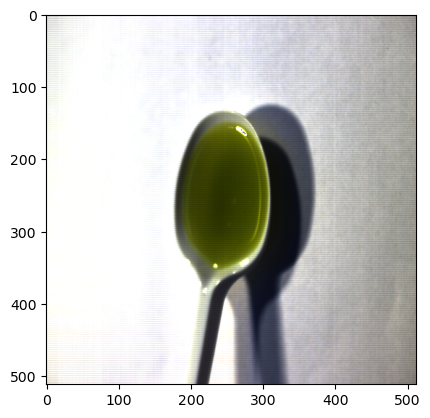

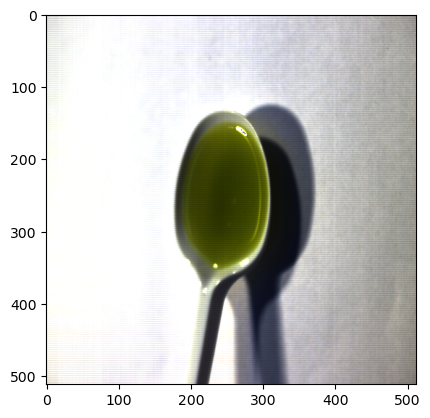

In [14]:
from utils.dataset import UniversalDataset
import pandas as pd
df = pd.read_excel('pivot_table.xlsx')
ds = UniversalDataset(root_dir='D:\\oil\\', meta=df, mask_dir='C:\\Users\\4spam\\evoo\\masking_business\\hand_masks\\', load_mask = True, crop_size = 512)
rgb = ds[90]['rgb']
plt.figure()
plt.imshow(rgb.permute(1, 2, 0))
rgb_r = ds[90]['hsi'][[70, 53, 19], :, :]
plt.figure()
plt.imshow(rgb.permute(1, 2, 0))
rgb = ds[90]['rgb'].unsqueeze(0).to(device)
rgb.shape

In [16]:
with torch.no_grad():
    prediction = model(rgb)
    prediction = prediction.squeeze(0).detach().to('cpu')
gt = ds[90]['hsi']

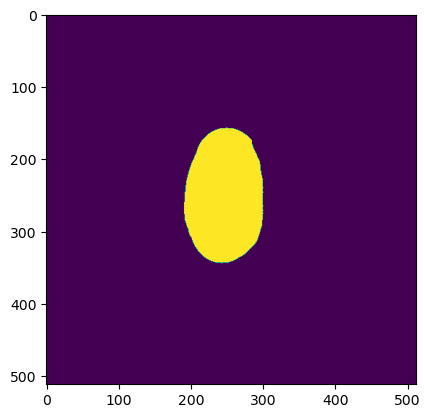

In [24]:
plt.imshow(ds[90]['mask'].squeeze(0))

In [48]:
list(waves).index(np.array([449.35]).astype('float32')[0])

18

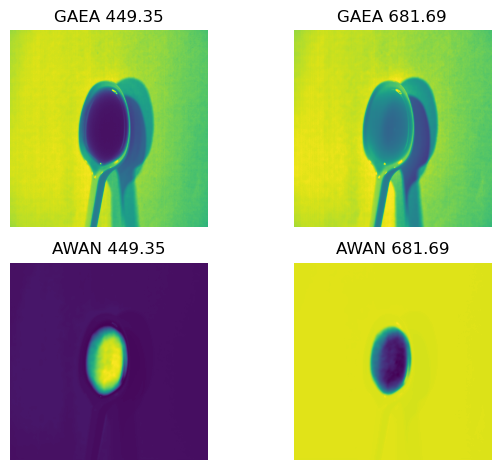

In [49]:
plt.subplot(2, 2, 1)  # 2 rows, 2 cols, position 1 (top-left)
plt.imshow(gt[18])
plt.title('GAEA 449.35')
plt.axis('off')

plt.subplot(2, 2, 2)  # Position 2 (top-right)
plt.imshow(gt[97])
plt.title('GAEA 681.69')
plt.axis('off')

# Second row
plt.subplot(2, 2, 3)  # Position 3 (bottom-left)
plt.imshow(prediction[18])
plt.title('AWAN 449.35')
plt.axis('off')

plt.subplot(2, 2, 4)  # Position 4 (bottom-right)
plt.imshow(prediction[97])
plt.title('AWAN 681.69')
plt.axis('off')

plt.tight_layout()  # Adjust spacing
plt.show()



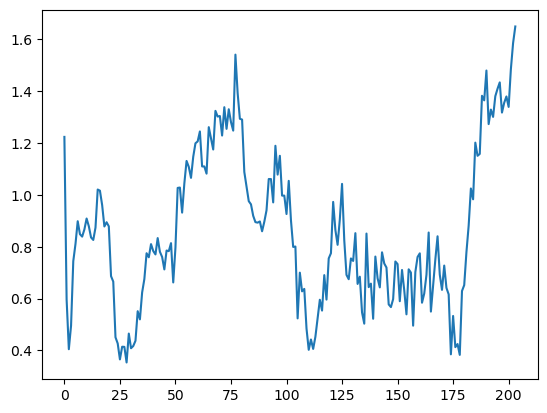

In [41]:
plt.plot(abs(gt - prediction).mean(1).mean(1))

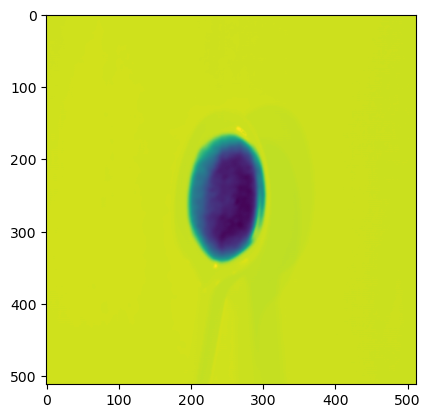

In [59]:
plt.imshow((prediction)[:, :, :][100])

In [50]:
m_gt = (ds[90]['mask'] * gt)[:, 200:300, 220:290].mean((1, 2))
m_pr = (ds[90]['mask'] * prediction)[:, 200:300, 220:290].mean((1, 2))

Text(0.5, 1.0, 'GAEA spectra at roi')

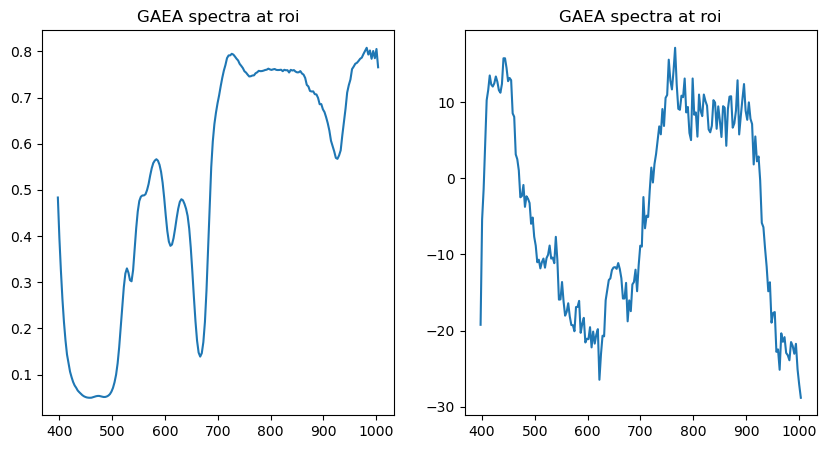

In [55]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(waves, m_gt)
plt.title('GAEA spectra at roi')
plt.subplot(1, 2, 2)
plt.plot(waves, m_pr)
plt.title('GAEA spectra at roi')

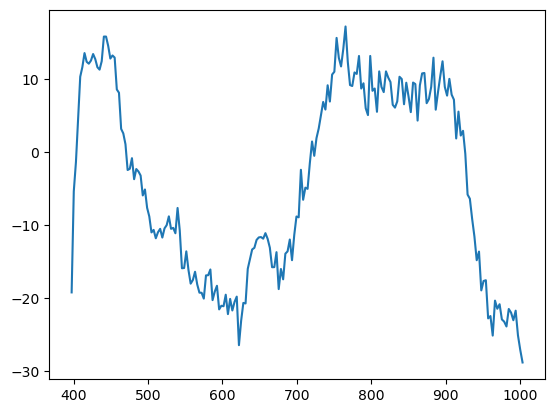

In [18]:
from torch.utils.data import DataLoader
test_dl = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

In [19]:
test_metrics = evaluate(model, test_dl, device)

In [21]:
test_metrics

{'rmse': 8.647079970809482, 'mrae': 10.999442067554343}

In [25]:
ds[0]['rgb'].shape

torch.Size([3, 512, 512])

In [ ]:
model(ds[0]['rgb'].unsqueeze(0).to(device))